In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
iris = load_iris()
x= iris.data # getting all the data from the iris data set
y = iris.target; #y is for 0 for setosa 1 for versicolor and 2 for virginica

In [4]:
# now choosing our two main petal length and width \
x_petal = x[:,2:4] # taking two last values

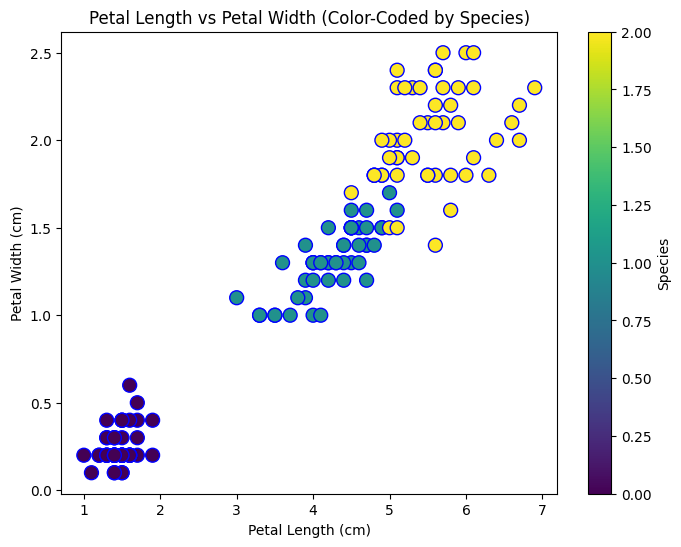

In [5]:
plt.figure(figsize=(8, 6))

# Create the scatter plot
plt.scatter(x_petal[:, 0], x_petal[:, 1], c=y, cmap='viridis', edgecolor='b', s=100)

# Label the axes
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

# Title
plt.title('Petal Length vs Petal Width (Color-Coded by Species)')

# Show the color bar for species
plt.colorbar(label='Species')

plt.show()

In [6]:
scaler = StandardScaler()
x_petal_scaled = scaler.fit_transform(x_petal)
x_scaled = scaler.fit_transform(x)

In [7]:
# doin pca
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_petal_scaled)

# Getiing eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Getting eigenvectors (principal 'components)
eigenvectors = pca.components_



In [8]:
print("Eigenvalues (Explained Variance):")
print(eigenvalues)

print("\nEigenvectors (Principal Components):")
print(eigenvectors)


Eigenvalues (Explained Variance):
[1.97603902 0.03738379]

Eigenvectors (Principal Components):
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [9]:
pca = PCA(n_components=4)
pca.fit(x_scaled)

eigenvalues = pca.explained_variance_

eigenvectors = pca.components_

print("Eigenvalues (Explained Variance):")
print(eigenvalues)

print("\nEigenvectors (Principal Components):")
print(eigenvectors)

Eigenvalues (Explained Variance):
[2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors (Principal Components):
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9468960016420045

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_pca,y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.949735143635091